## Atividade Otimização 
### Part 1 - Introdução
 - PPGCAP - INPE 2026.3
 - Dicente: William Max
 - Docente: Fabricio G


## TC.1

<h1>Titulo: Applying a Dynamic Data Driven Genetci Algorithm to Improve Forest Fire Spread Prediction</h1>

#### A) Qual problema está sendo resolvido.

        O artigo visa aplicar otimização para reduzir a incerteza dos dados de entrada em simuladores de incêndio florestal, possibilitando uma previsão mais acurada e alinhada com o crescimento real dos incêndios.


#### B) Em qual contexto a otimização está sendo efetuada e qual técnica é utilizada.

        A otimização ocorre no contexto de calibração de simuladores em tempo real sob o paradigma Dynamic Data Driven Application Systems (DDDAS), utilizando como técnica um Algoritmo Genético Guiado por Dados (Dynamic Data Driven GA). Classicamente, as predições de crescimento resolvem equações matemáticas dadas as entradas como declive e direção do vento. No paradigma DDDAS, esses parâmetros são atualizados dinamicamente com informações do mundo real. O GA, em vez de gerar números aleatórios, é guiado na seleção de valores condizentes com a evolução física do fogo, utilizando equações trigonométricas para deduzir vetores como a velocidade do vento a partir do ponto de máxima propagação observada.

#### C) Quais as variáveis de projeto/decisão do problema.

       As variáveis de decisão são os parâmetros ambientais calibrados: direção do vento, velocidade do vento, umidade do combustível vivo e umidade do combustível morto (avaliada em três tempos distintos). A aclividade foi considerado um fator estático por não ter muita variação. 

#### D) Como uma solução candidata é representada na obtenção da solução ótima.

       Uma solução candidata é representada computacionalmente como um conjunto de números cada um desses é o valor específico testado para as variáveis de decisão (ventos e umidades), compondo um "indivíduo" que representa um cenário ambiental único a ser simulado.

#### E) Qual o critério de avaliação da solução (i.e., função objetivo).

        Minimizar o erro de propagação, medido pela diferença de semelhança espacial entre o mapa de fogo simulado e o mapa de fogo real observado.

#### F) Qual/quais os critérios de parada utilizados.

       O limite máximo de 5 iterações (gerações), estabelecido porque a redução do erro se torna insignificante a partir da terceira ou quarta iteração.

##### g) Quais as restrições do problema de otimização e como elas são tratadas.

        Não há penalizações na função objetivo como no GA clássico para mutações incompatíveis com a realidade, o que otimiza o custo computacional. As restrições do espaço de busca são tratadas por engenharia reversa. O sistema analisa a posição real do fogo e o declive topográfico para deduzir analiticamente os vetores do vento. Esses dados deduzidos são injetados nas operações de elitismo e mutação, restringindo o GA a buscar soluções apenas em zonas com viabilidade física comprovada.



## TC.2 - f : Empresarial, com foco na área de produção.

<h3>Uma estamparia automotiva fabrica duas peças de lataria para montadoras: capôs e portas. Para a operação diária, a fábrica dispõe de bobinas de aço que fornecem um total de 200 m² de chapa utilizável. O chão de fábrica opera com uma equipe de 5 funcionários em um turno de 8 horas, totalizando uma capacidade máxima de 40 horas de mão de obra por dia.

A ficha técnica dos produtos determina que a estampagem de um único capô consome 15 m² de chapa de aço e requer 3 horas de trabalho da equipe. A produção de uma porta consome 10 m² de material e exige 2 horas de trabalho. Sabendo que a margem de lucro operacional é de R$ 150,00 por capô e R$ 100,00 por porta.</h3>

1 - O espaço de busca:

O espaço de busca é o conjunto dos números inteiros não-negativos ($\mathbb{Z}^2_{\ge 0}$).$$x_1, x_2 \in \{0, 1, 2, 3, \dots\}$$ ; $x_1$ (Quantidade de portas) e $x_2$ (Quantidade capôs)

Restrições: 
1 - Material: 

$$15x_1 + 10x_2 \le 200$$

2 - Mão de obra: 

        São necessários 5 funcionários (2 para uma porta e 3 para um capõ) gerando a relação homens-hora, considerando a escala de 8h diárias 5 funcionários implica em 40h de produção, logo:

$$3x_1 + 2x_2 \le 40$$

3. Restrição de Não-Negatividade:É fisicamente impossível estampar quantidades negativas.$$x_1 \ge 0$$ $$x_2 \ge 0$$



Função Objetivo:

Maximizar o lucro diário da estamparia.

$$\min \ [-f(x_1, x_2)]$$

$$\min_{(x_1, x_2) \in \Chi} \ -(150x_1 + 100x_2)$$

$$\Chi = \Big\{ (x_1, x_2) \in \mathbb{Z}_{\ge 0}^2 \ \Big\vert{} \ 15x_1 + 10x_2 \le 200 \quad \text{e} \quad 3x_1 + 2x_2 \le 40 \Big\}$$


3 - Critério de parada:

Tempo de execução para cenários massivos;

Encontrar a combinação de x_1 e x_2 que maximiza o valor de f(x) ao esgotar o conjunto factível. 

Definir o método

Dizer o que é um simplex

Explicar operações

explicar comparações e procediemtnos

### PC.4.A

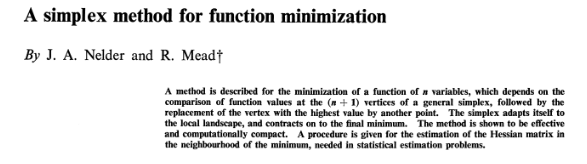

O algoritmo de Nelder-Mead foi desenvolvido em 1965 por John Nelder e Roger Mead. Consiste em um método iterativo que explora o espaço de busca a fim de obter um mínimo local. Por ser um método de busca direta que não utiliza informações de derivadas (gradientes), mostra-se uma excelente alternativa para funções descontínuas, ruidosas ou com derivadas muito custosas de serem computadas. O algoritmo baseia-se essencialmente em transformações geométricas e depende de um ponto de partida para definir um símplex — o polítopo mais simples do espaço —, que é formado por $N+1$ vértices, onde $N$ é a dimensão do problema. A busca avança substituindo o pior vértice a cada passo, utilizando operações de reflexão, expansão, contração e encolhimento.

<p align="center">
  <img src="/home/william/Desktop/manager/Pos/otimizacao/Screenshot_2026-10-05_22-49-32.png" alt="Descrição da imagem" width="500"/>
</p>

<p align="center">
  <img src="attachment:image.png" width="500"/>
</p>

Uma referência para melhor compreenção do algoritmo: https://www.mql5.com/pt/articles/13805 

1. Preparação
- Gerar Símplex com $N+1$ vértices.
- Ordenar vértices: Melhor ($x_1$) $\rightarrow$ Pior ($x_{n+1}$).

2. Verificação de Parada
- Tolerância atingida? $\rightarrow$ FIM (Retorna $x_1$).
- Continuar caso contrário.

3. Reflexão
- Calcular Centroide ($x_o$) ignorando o pior ponto.
- Refletir o pior ponto através de $x_o$ $\rightarrow$ Gerar $x_r$.
- Se $x_r$ for intermediário $\rightarrow$ Substitui o pior por $x_r$ $\rightarrow$ Voltar ao passo 1.

4. Expansão (Se a reflexão for excelente)
- Se $x_r$ for o novo melhor absoluto $\rightarrow$ Expandir para $x_e$.
- Substitui o pior pelo melhor entre $x_r$ e $x_e$ $\rightarrow$ Voltar ao passo 1.

5. Contração (Se a reflexão for ruim)
- Se $x_r$ for pior que o segundo pior $\rightarrow$ Recuar e gerar $x_c$.
- Se $x_c$ for melhor que o pior atual $\rightarrow$ Substitui o pior por $x_c$ $\rightarrow$ Voltar ao passo 1.

6. Encolhimento / Shrink (Se tudo falhar)
- Manter o melhor ponto ($x_1$) fixo.Encolher todos os outros vértices em direção a $x_1$ $\rightarrow$ Voltar ao passo 1.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

#### Funções auxiliares

In [19]:
def define_simplex(kickoff, step):
    """Cria os vértices do simplex a partir de um ponto inicial e um step."""
    dim = len(kickoff)
    
    simplex = [kickoff]

    for i in range(dim):
        new_point = kickoff.copy()  
        new_point[i] += step        
        simplex.append(new_point)  
    
    return np.array(simplex)      

In [20]:
def centroid (goods_points):
    """Determina o centroid sem o pior elemento"""
    return np.mean(goods_points, axis=0)

In [21]:
def select_good_points(new_simplex, func):
    """
    Avalia a função nos pontos do simplex, ordena do melhor para o pior,
    e separa os pontos que usaremos para o centroide.
    """

    #passa os pontos na função e ordena os simplex de modo crecente conforme f(simplex)
    simplex_ordenado = sorted(new_simplex, key=func)
    
    goods_points = simplex_ordenado[:-1]
    
    worst_point = simplex_ordenado[-1]
    
    return simplex_ordenado, goods_points, worst_point

#### Motor

In [22]:
def iteracao_nelder_mead(simplex, func):
    # parâmetros que vi na literatura e uso
    alpha = 1
    gamma = 2
    rho = sigma =0.5 

    simplex_ordenado, goods_points, worst_point = select_good_points(simplex, func)

    centroide = centroid(goods_points)

    ponto_refletido = centroide + alpha*(centroide - worst_point)


    best_point = simplex_ordenado[0]

    ponto_refletido_value = func(ponto_refletido)
    best_point_value = func(simplex_ordenado[0])
    befor_wrost_value= func(simplex_ordenado[-2])
    worst_value = func(simplex_ordenado[-1])

    # 4. A Árvore de Decisão
    if ponto_refletido_value < best_point_value:
        # Entense-se que é um declive e o empurra para um lugar mais
        ponto_expandido = centroide + gamma*(ponto_refletido - centroide)
        #Teste para validar o ponto exandido não estra em um aclive
        ponto_expandido_value = func(ponto_expandido)
        
        # Só aceita a expansão se ela for realmente melhor que a reflexão
        if ponto_expandido_value < ponto_refletido_value:
            simplex_ordenado[-1] = ponto_expandido
        else:
            simplex_ordenado[-1] = ponto_refletido


    elif ponto_refletido_value < befor_wrost_value:
    
        simplex_ordenado[-1] = ponto_refletido
        
    else:

        if ponto_refletido_value < worst_value: 
            ref = ponto_refletido
        else: 
            ref = worst_point
            
        ponto_retracao = centroide + rho * (ref - centroide)
        ponto_retracao_value = func(ponto_retracao)
        
        # Testa se a contração realmente ajudou
        if ponto_retracao_value < worst_value:
            simplex_ordenado[-1] = ponto_retracao
        else:
            #Encolhimento (Shrink)
            for i in range(1, len(simplex_ordenado)):
                ponto_encolhido = best_point + sigma * (simplex_ordenado[i] - best_point)
                simplex_ordenado[i] = ponto_encolhido
        
    return simplex_ordenado
        

#### Chamada prinncipal

In [17]:
def nelder_mead_otimizador(func, kickoff, step=1.0, tol=1e-6, max_iter=1000):
    """
    Wrapper principal que executa o Nelder-Mead.
    """
    simplex = define_simplex(kickoff, step)

    historico_simplex = [simplex.copy()]
    
    iters = 0
    while iters < max_iter: # Critério parada

        # Verificação do f(simplex)
        valores = np.array([func(p) for p in simplex])
        
        # Se o desvio padrão das altitudes for menor que a tolerância,
        # significa que os vértices encolheram tanto sulficientemente
        if np.std(valores) < tol:
            break
            
        simplex = iteracao_nelder_mead(simplex, func)

        historico_simplex.append(simplex.copy())
        
        iters += 1

    #Uma garantia testee
    valores_finais = np.array([func(p) for p in simplex])
    indice_melhor = np.argsort(valores_finais)[0]
    
    melhor_ponto = simplex[indice_melhor]
    melhor_valor = valores_finais[indice_melhor]
    
    return melhor_ponto, melhor_valor, iters, historico_simplex

#### Testes

In [23]:
def funcao_himmelblau(ponto):
    x, y = ponto[0], ponto[1]
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

O algoritmo Nelder-Mead deve ir para em um destes quatro mínimos, dependendo de onde iniciar o kickoff: 
$$f(3.0, 2.0) = 0.0$$
$$f(-2.805118, 3.131312) = 0.0$$
$$f(-3.779310, -3.283186) = 0.0$$
$$f(3.584428, -1.848126) = 0.0$$

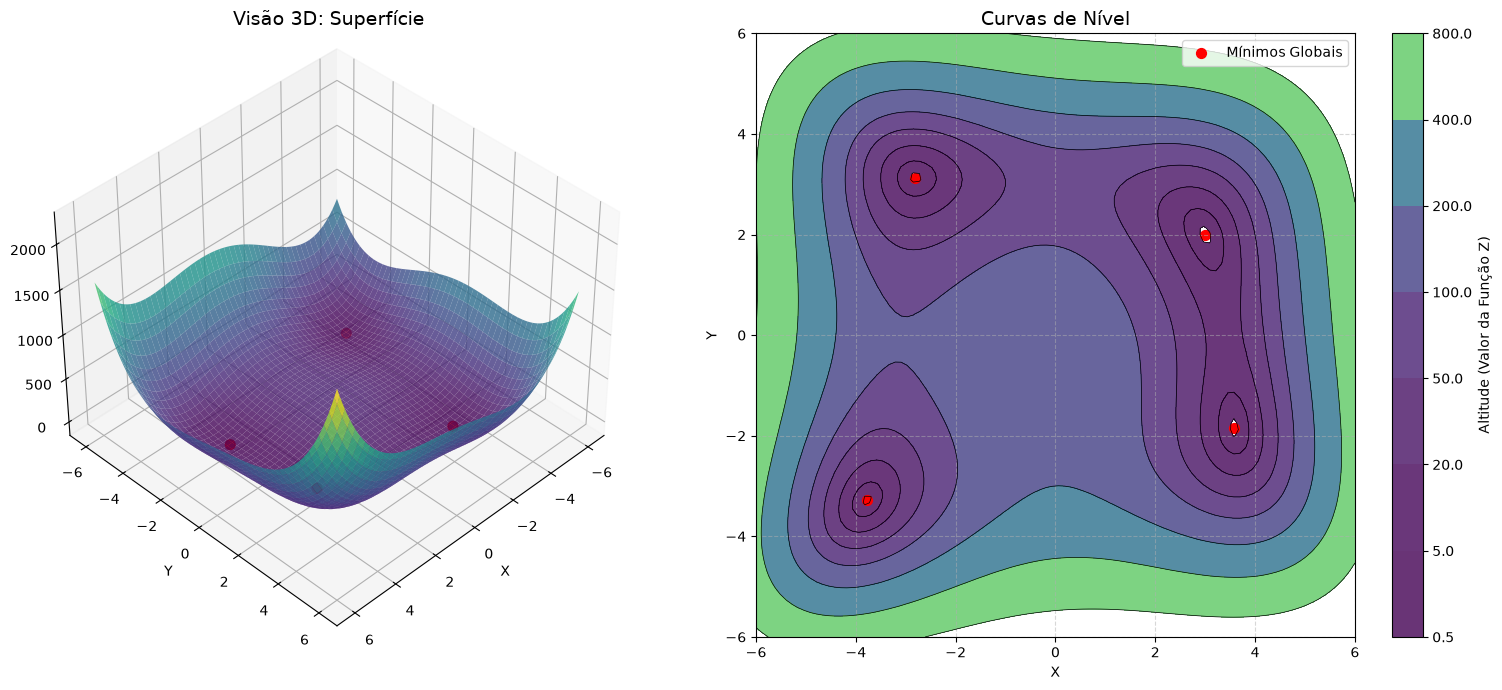

In [24]:
#=========================================
# PLOT
#=========================================

x = np.linspace(-6, 6, 100)
y = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x, y)
Z = funcao_himmelblau([X, Y])


fig = plt.figure(figsize=(16, 7))



minimos_x = [3.0, -2.805118, -3.779310, 3.584428]
minimos_y = [2.0, 3.131312, -3.283186, -1.848126]
minimos_z = [0.0, 0.0, 0.0, 0.0]

# --- GRÁFICO 1: Superfície 3D (Posição 1 de 2) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
superficie = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.scatter(minimos_x, minimos_y, minimos_z, color='red', s=50, label='Mínimos Globais')
ax1.set_title("Visão 3D: Superfície", fontsize=14)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.view_init(elev=40, azim=45)

# --- GRÁFICO 2: Curvas de Nível 2D (Posição 2 de 2) ---
ax2 = fig.add_subplot(1, 2, 2)
# def dos níveis
niveis = [0.5, 5, 20, 50, 100, 200, 400, 800]
# contourf cria o preenchimento de cor, contour desenha as linhas
contorno = ax2.contourf(X, Y, Z, levels=niveis, cmap='viridis', alpha=0.8)
ax2.contour(X, Y, Z, levels=niveis, colors='black', linewidths=0.5)

# Desenhando os mínimos no mapa 2D
ax2.scatter(minimos_x, minimos_y, color='red', s=50, label='Mínimos Globais')
ax2.set_title("Curvas de Nível", fontsize=14)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

# Barra de cores para referência do Gráfico 2
fig.colorbar(contorno, ax=ax2, label='Altitude (Valor da Função Z)')

plt.tight_layout()
plt.show()

In [25]:
def funcao_esfera(ponto):
    x, y = ponto[0], ponto[1]
    return (x-1)**2 + (y+2)**2

In [41]:
# 2. BUSCA EXAUSTIVA (GRID SEARCH)
# ============================================================
def busca_exaustiva(func, limites_x=(-6.0, 6.0), limites_y=(-6.0, 6.0), passo=0.05):
    """
    Varre um grid bidimensional avaliando a função em cada ponto.
    Registra: histórico de pontos onde um novo mínimo foi encontrado
    """
    xs = np.arange(limites_x[0], limites_x[1] + passo / 2, passo)
    ys = np.arange(limites_y[0], limites_y[1] + passo / 2, passo)
    
    melhor_ponto = None
    melhor_valor = float('inf')
    historico_melhorias = []
    total_avaliacoes = 0
    
    for x in xs:
        for y in ys:
            total_avaliacoes += 1
            pt = np.array([x, y])
            val = func(pt)
            
            if val < melhor_valor:
                melhor_valor = val
                melhor_ponto = pt.copy()
                historico_melhorias.append({
                    'ponto': pt.copy(),
                    'valor': val,
                    'avaliacao': total_avaliacoes
                })
                
    return melhor_ponto, melhor_valor, total_avaliacoes, historico_melhorias


In [49]:
# Chute inicial
kickoff = np.array([0.0, 0.0])

# Executando 
ponto_nm, valor_nm, iters_nm, historico = nelder_mead_otimizador(funcao_himmelblau, kickoff, step=9)

print("=== NELDER-MEAD ===")
print(f"Ponto ótimo encontrado: [{ponto_nm[0]:.4f}, {ponto_nm[1]:.4f}]")
print(f"Valor da função: {valor_nm:.8f}")
print(f"Iterações gastas: {iters_nm}")
print(f"Simplexes armazenados para animação: {len(historico)}")


=== NELDER-MEAD ===
Ponto ótimo encontrado: [-2.8050, 3.1314]
Valor da função: 0.00000070
Iterações gastas: 34
Simplexes armazenados para animação: 35


In [45]:
# Executando a Busca Exaustiva em [-6, 6] x [-6, 6] com passo de 0.05
PASSO  = 0.001
ponto_ex, valor_ex, total_avaliacoes, historico_melh = busca_exaustiva(funcao_himmelblau, passo=PASSO)

print("=== BUSCA EXAUSTIVA ===")
print(f"Ponto ótimo encontrado: [{ponto_ex[0]:.4f}, {ponto_ex[1]:.4f}]")
print(f"Valor da função: {valor_ex:.8f}")
print(f"Total de pontos testados: {total_avaliacoes}")


=== BUSCA EXAUSTIVA ===
Ponto ótimo encontrado: [3.0000, 2.0000]
Valor da função: 0.00000000
Total de pontos testados: 144024001


In [46]:
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Polygon
from IPython.display import HTML
def animar_caminhada(historico_nelder, historico_busca, func=funcao_himmelblau, passo=0.05):
    """
    Animação comparativa sincronizada:
      - historico_nelder: lista com os simplexes do Nelder-Mead
      - historico_busca: lista com os pontos de melhoria da busca exaustiva
    """
    minimos = np.array([
        [3.0, 2.0],
        [-2.805118, 3.131312],
        [-3.779310, -3.283186],
        [3.584428, -1.848126]
    ])
    # 1. Curvas de nível de fundo
    x_grid = np.linspace(-5.5, 5.5, 100)
    y_grid = np.linspace(-5.5, 5.5, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = func([X, Y])
    niveis = [0.5, 5, 20, 50, 100, 200, 400, 800]
    # Malha da busca exaustiva para calcular o ponto de varredura
    xs = np.arange(-6.0, 6.0 + passo / 2, passo)
    ys = np.arange(-6.0, 6.0 + passo / 2, passo)
    total_pontos = len(xs) * len(ys)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=90)
    # --- Subplot 1: Nelder-Mead ---
    ax1.contourf(X, Y, Z, levels=niveis, cmap='viridis', alpha=0.7)
    ax1.contour(X, Y, Z, levels=niveis, colors='black', linewidths=0.5)
    ax1.scatter(minimos[:, 0], minimos[:, 1], color='red', s=45, zorder=5, label='Mínimos Globais')
    
    tri_patch = Polygon(historico_nelder[0], closed=True, facecolor='cyan', edgecolor='blue', linewidth=2, alpha=0.6, zorder=4)
    ax1.add_patch(tri_patch)
    line_nm, = ax1.plot([], [], 'w--', linewidth=1.5, zorder=3, label='Trajetória Simplex')
    pt_nm_best = ax1.scatter([], [], color='yellow', s=50, edgecolors='black', zorder=6, label='Melhor Vértice')
    ax1.set_xlim(-5.5, 5.5)
    ax1.set_ylim(-5.5, 5.5)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.legend(loc='upper left', fontsize=8)
    # --- Subplot 2: Busca Exaustiva ---
    ax2.contourf(X, Y, Z, levels=niveis, cmap='viridis', alpha=0.7)
    ax2.contour(X, Y, Z, levels=niveis, colors='black', linewidths=0.5)
    ax2.scatter(minimos[:, 0], minimos[:, 1], color='red', s=45, zorder=5, label='Mínimos Globais')
    
    # Elementos da varredura na Busca Exaustiva
    line_scan = ax2.axvline(x=-5, color='white', linestyle=':', alpha=0.6, label='Frente de Varredura')
    scat_curr_ex = ax2.scatter([], [], color='white', edgecolors='black', s=70, zorder=6, label='Ponto Varredura')
    scat_best_ex = ax2.scatter([], [], color='magenta', s=100, marker='*', zorder=7, label='Melhor Corrente')
    line_traj_ex, = ax2.plot([], [], 'm--', alpha=0.7, linewidth=1.2, label='Caminho de Melhorias')
    
    ax2.set_xlim(-5.5, 5.5)
    ax2.set_ylim(-5.5, 5.5)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.legend(loc='upper left', fontsize=8)
    n_frames = len(historico_nelder)
    def update(frame):
        # 1. Atualiza Nelder-Mead
        simplex = historico_nelder[frame]
        tri_patch.set_xy(simplex)
        
        melhores = [s[np.argmin([func(p) for p in s])] for s in historico_nelder[:frame+1]]
        melhores = np.array(melhores)
        line_nm.set_data(melhores[:, 0], melhores[:, 1])
        pt_nm_best.set_offsets([melhores[-1]])
        v_nm = func(melhores[-1])
        ax1.set_title(f'Nelder-Mead | Iteração: {frame+1}/{n_frames}\nf(x, y) = {v_nm:.6f}', fontsize=11)
        # 2. Atualiza Busca Exaustiva
        frac = (frame + 1) / n_frames
        idx = int(frac * (total_pontos - 1))
        x_scan = xs[idx // len(ys)]
        y_scan = ys[idx % len(ys)]
        
        # Move a frente de varredura e o ponto branco
        line_scan.set_xdata([x_scan, x_scan])
        scat_curr_ex.set_offsets([[x_scan, y_scan]])
        
        # Encontra o melhor ponto até o número de avaliações atual
        melhor_atual = historico_busca[0]
        pts_melhores = []
        for item in historico_busca:
            if item['avaliacao'] <= (idx + 1):
                melhor_atual = item
                pts_melhores.append(item['ponto'])
            else:
                break
                
        scat_best_ex.set_offsets([melhor_atual['ponto']])
        if len(pts_melhores) > 0:
            pts_arr = np.array(pts_melhores)
            line_traj_ex.set_data(pts_arr[:, 0], pts_arr[:, 1])
            
        ax2.set_title(f'Busca Exaustiva | Avaliações: {idx+1}/{total_pontos}\nMelhor f(x, y) = {melhor_atual["valor"]:.6f}', fontsize=11)
        return tri_patch, line_nm, pt_nm_best, line_scan, scat_curr_ex, scat_best_ex, line_traj_ex
    anim = FuncAnimation(fig, update, frames=n_frames, interval=250, blit=False)
    plt.close(fig)
    return anim

In [50]:
anim = animar_caminhada(historico, historico_melh, passo=PASSO)
HTML(anim.to_jshtml())
